# MOSAIC -- Global Optimization Phase (clustering, $\alpha=1$, $\beta=0$)

Reads `exp_global.py`'s output and plots the clustering-quality metrics
(see `src/global_opt.py`): pairwise F1 (network-wide micro-average) and ARI
(macro-averaged over mechanisms), for MOSAIC (W-2/W-3) against two
baselines -- the local-IDM "no update" ablation and the naive MLE
point-estimate baseline (oracle $k$, see `cluster_1d_wcss_optimal`).

Facet grid mirrors `plot.ipynb` (the local phase): rows = ($\rho$,
$\alpha$) combinations, columns = ($E$, $S$) combinations, $N$ (sample
size) on the x-axis -- so this keeps working unchanged if `conf_global.yaml`
is extended to sweep `n_clients` or `prob_shift`/`alpha` too, not just $S$
and $N$ as it currently does.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa


In [2]:
# Read config file
config = load_config("conf_global.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp_global.py) -- each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

df_tot = pd.read_csv(res_path / "df_tot.csv")
df_tot.head()


,n_clients,ess,prob_shift,alpha,size,rep,mos_w2_precision,mos_w2_recall,mos_w2_f1,mos_w2_ari,...,noupdate_ari,noupdate_ami,noupdate_n_clusters_mean,mle_precision,mle_recall,mle_f1,mle_ari,mle_ami,mle_n_clusters_mean,n_clusters_true_mean
0,10,2,0.5,0.1,55,0,0.262009,0.487805,0.340909,0.008381,...,0.166328,0.179140,2.7,0.303797,0.195122,0.237624,-0.004005,-0.006648,5.6,5.6
1,10,2,0.5,0.1,55,1,0.311594,0.666667,0.424691,0.008080,...,0.186666,0.199679,2.3,0.467890,0.395349,0.428571,0.095854,0.097843,5.6,5.6
2,10,2,0.5,0.1,55,4,0.294326,0.488235,0.367257,-0.015672,...,0.116308,0.132085,2.1,0.654676,0.535294,0.588997,0.206872,0.216029,4.9,4.9
3,10,2,0.5,0.1,55,2,0.165584,0.629630,0.262211,-0.051806,...,0.036273,0.052421,2.1,0.194030,0.160494,0.175676,0.022523,0.011270,6.6,6.6
4,10,2,0.5,0.1,5,2,0.288026,0.706349,0.409195,0.058494,...,0.020186,0.033475,1.4,0.363636,0.285714,0.320000,-0.016884,-0.001417,5.8,5.8


## Aggregation

Every numeric column already lives at the (hyperparameter combination x
repetition) level; group by every grid hyperparameter (not just the ones
that vary in the current `conf_global.yaml`, so this still works if the
grid is extended later) and take mean/std across repetitions.


In [3]:
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
metric_cols = [c for c in df_tot.columns if c not in group_cols + ["rep"]]

agg = df_tot.groupby(group_cols)[metric_cols].agg(["mean", "std"])
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
df_mean = agg.reset_index()
df_mean.head()


,n_clients,ess,prob_shift,alpha,size,mos_w2_precision_mean,mos_w2_precision_std,mos_w2_recall_mean,mos_w2_recall_std,mos_w2_f1_mean,...,mle_f1_mean,mle_f1_std,mle_ari_mean,mle_ari_std,mle_ami_mean,mle_ami_std,mle_n_clusters_mean_mean,mle_n_clusters_mean_std,n_clusters_true_mean_mean,n_clusters_true_mean_std
0,10,2,0.5,0.1,5,0.238691,0.057990,0.697440,0.063100,0.352804,...,0.311948,0.074148,0.020925,0.087069,0.021622,0.099994,6.00,0.478423,6.00,0.478423
1,10,2,0.5,0.1,55,0.264867,0.048414,0.583983,0.065571,0.360320,...,0.354585,0.118438,0.062056,0.069992,0.066548,0.076177,5.67,0.510011,5.67,0.510011
2,10,2,0.5,0.1,105,0.175697,0.053328,0.549271,0.080276,0.261744,...,0.245594,0.125555,0.021546,0.096277,0.015887,0.119355,6.51,0.653962,6.51,0.653962
3,10,2,0.5,0.1,155,0.223510,0.036679,0.528395,0.105312,0.311264,...,0.290541,0.102195,0.040554,0.079545,0.041740,0.101884,6.06,0.427395,6.06,0.427395
4,10,2,0.5,0.1,205,0.264296,0.061934,0.502689,0.092504,0.343816,...,0.365895,0.089229,0.074992,0.066517,0.076023,0.084535,5.80,0.382971,5.80,0.382971


In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        "figure.figsize": [7, 4],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "lines.linewidth": 1.0,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "text.usetex": True,
    }
)


## Methods and facets

Same facet convention as the local phase's `plot.ipynb`: rows =
($\rho$, $\alpha$) combinations, columns = ($E$, $S$) combinations. $N$
(sample size) is the x-axis, since `conf_global.yaml` now sweeps it
explicitly (an exploratory sweep found MOSAIC's gain over the no-update
ablation depends on $S$ *relative to* $N$, not $S$ alone -- see
`cap6_extract.tex`/`conf_global.yaml`'s own comments). Column titles show
just $S$ when `n_clients` has a single value (as now), and both $E$ and
$S$ once it is actually swept, to stay unambiguous.


In [5]:
METHODS = ("mos_w2", "mos_w3", "noupdate", "mle")
method_colors = {
    "mos_w2": "#4fc685",
    "mos_w3": "#9a97f4",
    "noupdate": "#fc9167",
    "mle": "#888888",
}
method_labels = {
    "mos_w2": "MOSAIC (W-2: intersection)",
    "mos_w3": "MOSAIC (W-3: JSD-based)",
    "noupdate": "No update (local IDM)",
    "mle": "MLE point-estimate (oracle $k$)",
}

# Facet grid: rows = (prob_shift, alpha) combinations, columns =
# (n_clients, ess) combinations -- exactly plot.ipynb's convention.
row_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None))
)
col_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
print(
    f"Grid: {len(row_vals)} row(s) (prob_shift, alpha) x {len(col_vals)} col(s) (n_clients, ess)"
)

_n_clients_vals = sorted(df_mean["n_clients"].unique())


def row_label(p, a):
    # alpha is irrelevant (and deduplicated away, see exp.hyperparameter_combos)
    # whenever prob_shift == 0.0.
    return fr"$\rho={p}$" if p == 0 else fr"$\rho={p}$, $\alpha={a}$"


def col_title(nc, ess):
    # Show E too once n_clients is actually swept (more than one value);
    # otherwise stay as compact as the local phase's own column titles.
    return fr"$E={nc}$, $S={ess}$" if len(_n_clients_vals) > 1 else fr"$S={ess}$"


def plot_metric(metric, ylabel, ylim=None, hline=None):
    fig, axes = plt.subplots(
        len(row_vals),
        len(col_vals),
        figsize=(4.5 * len(col_vals), 3.3 * len(row_vals)),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    for i, (p, a) in enumerate(row_vals):
        for j, (nc, ess) in enumerate(col_vals):
            ax = axes[i][j]
            sub = df_mean[
                (df_mean["prob_shift"] == p)
                & (df_mean["alpha"] == a)
                & (df_mean["n_clients"] == nc)
                & (df_mean["ess"] == ess)
            ].sort_values("size")

            if hline is not None:
                ax.axhline(hline, color="gray", linewidth=0.7, linestyle=":")
            for m in METHODS:
                mean = sub[f"{m}_{metric}_mean"]
                std = sub[f"{m}_{metric}_std"]
                ax.fill_between(
                    sub["size"], mean - std, mean + std, color=method_colors[m], alpha=0.15
                )
                ax.plot(
                    sub["size"], mean, color=method_colors[m], marker="o", label=method_labels[m]
                )

            if i == 0:
                ax.set_title(col_title(nc, ess), fontsize=9)
            if j == 0:
                ax.set_ylabel(f"{row_label(p, a)}\n{ylabel}", fontsize=8)
            if i == len(row_vals) - 1:
                ax.set_xlabel("$N$")
            if ylim:
                ax.set_ylim(*ylim)

    axes[0][-1].legend(loc="best", fontsize=6)
    plt.tight_layout()
    return fig


Grid: 2 row(s) (prob_shift, alpha) x 3 col(s) (n_clients, ess)


## Grafico 1: pairwise F1 (network-wide, micro-averaged)

Every client pair, of every mechanism $(X, \pi_X)$, in one repetition is
pooled into a single confusion matrix before computing precision/recall/F1
(see `src/global_opt.py::pairwise_confusion`) -- the natural aggregation
here, since P/R/F1 are properties of individual client pairs and every
mechanism contributes the same number of pairs. Band is mean $\pm$ 1 std
**across repetitions**.


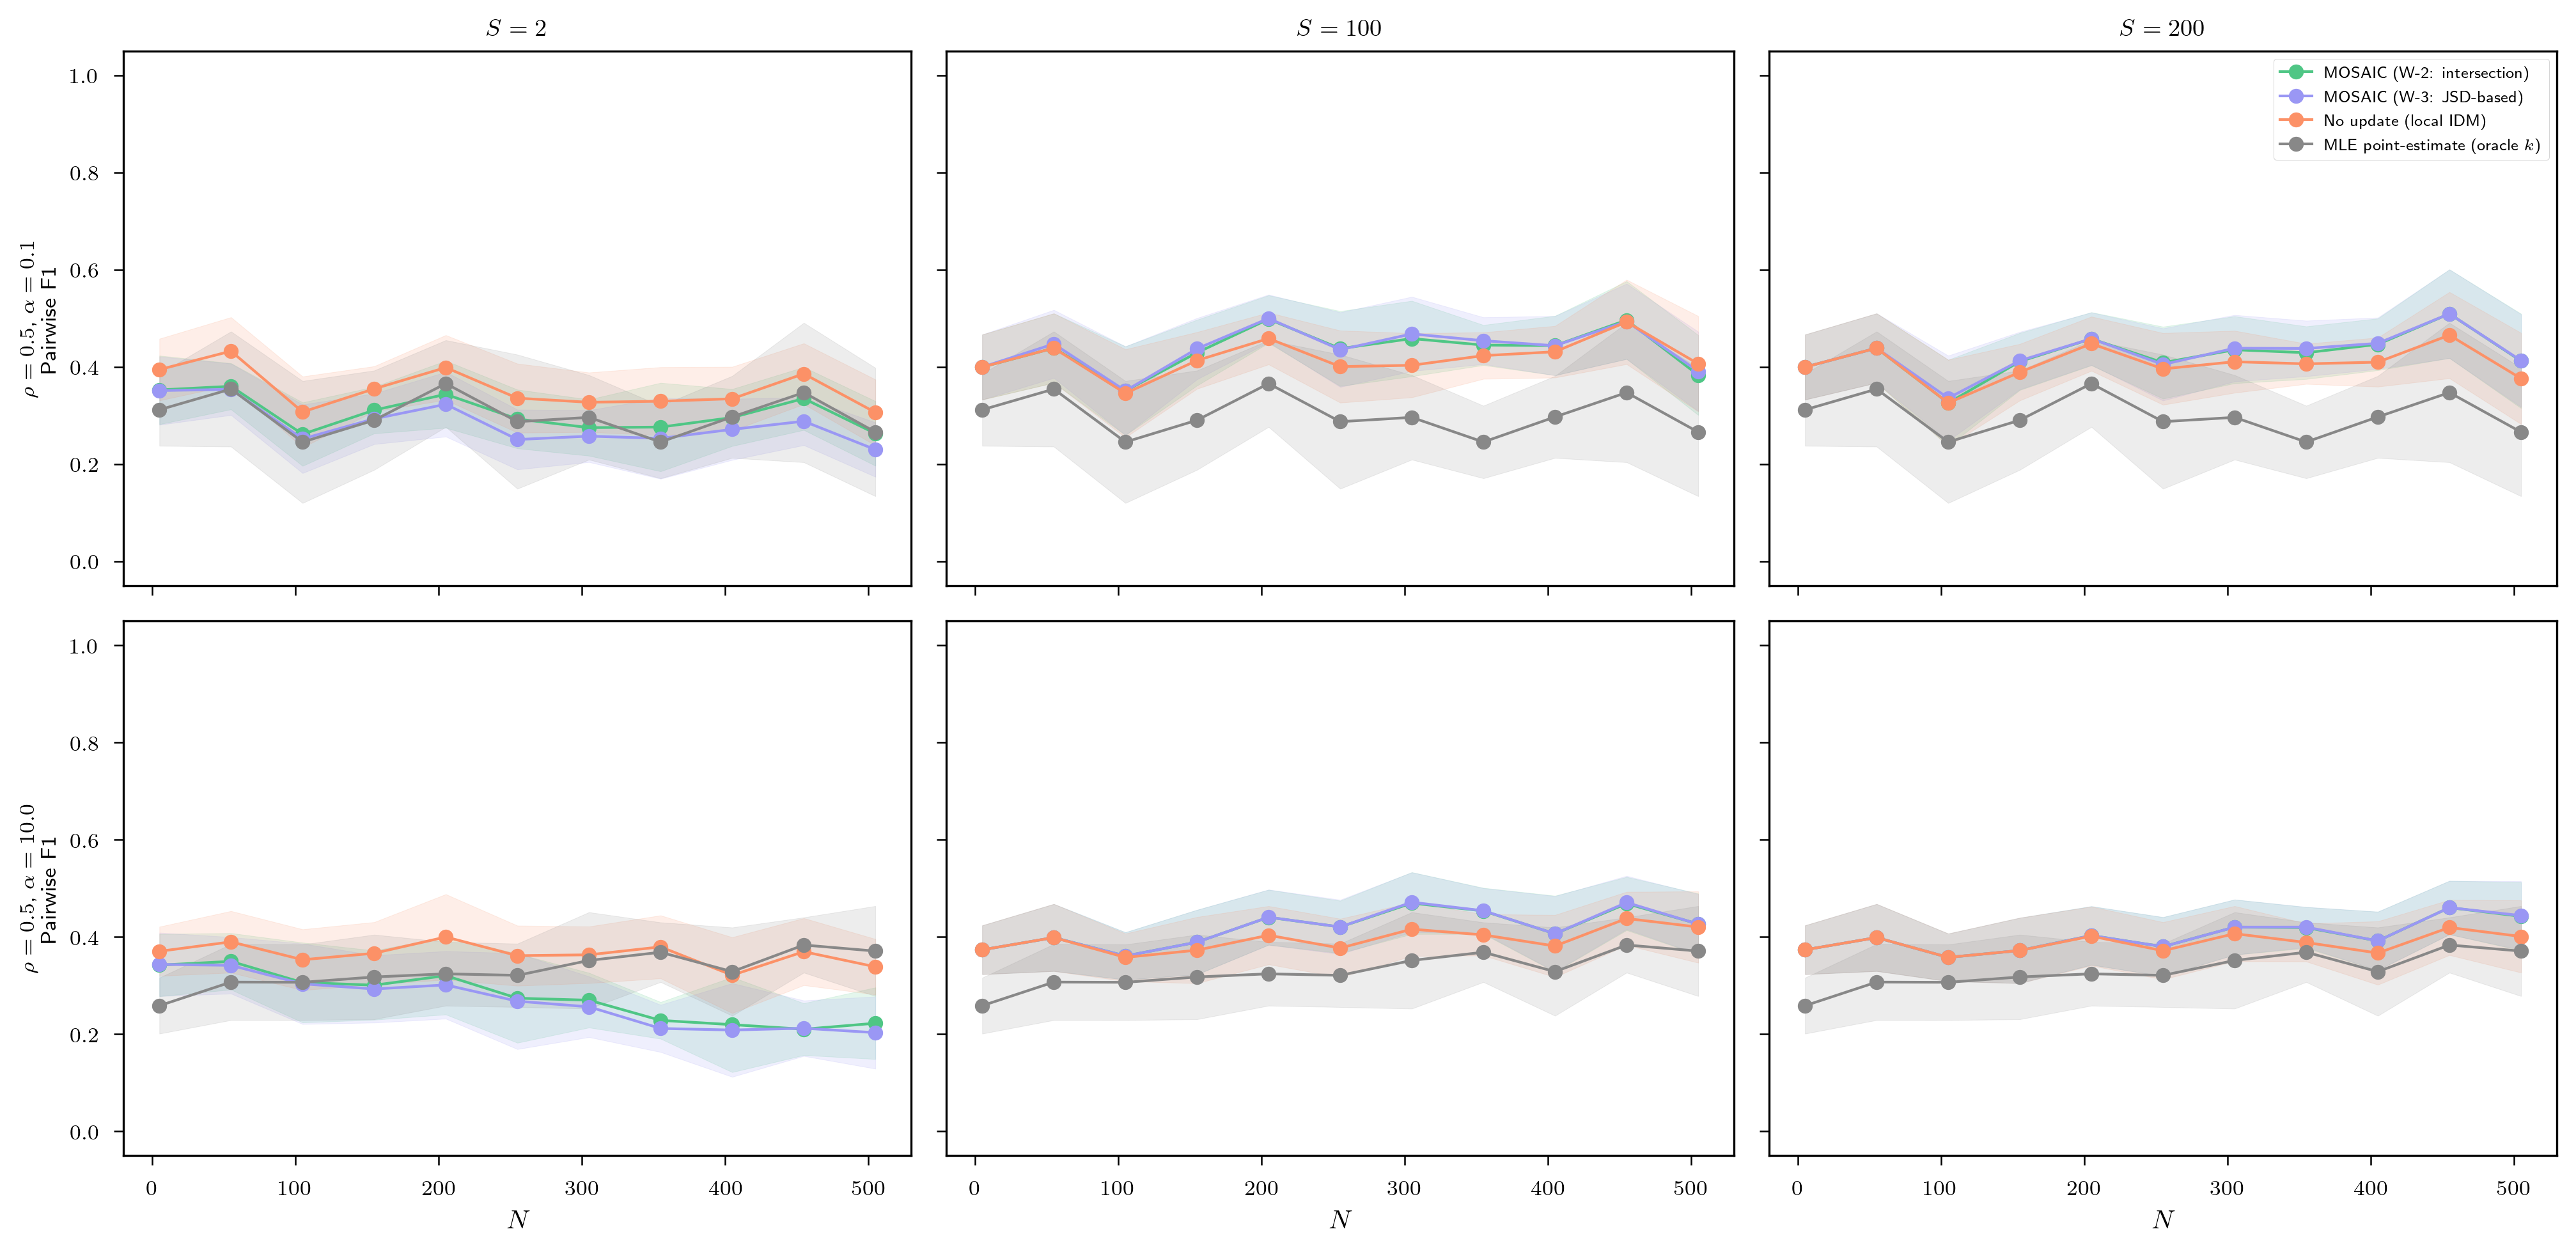

In [6]:
fig = plot_metric("f1", "Pairwise F1", ylim=(-0.05, 1.05))
plt.show()
fig.savefig(f"{res_path}_f1.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 1.1: precision (network-wide, micro-averaged)

Of all the client pairs a method declared *same* (same mechanism), what
fraction really are (pooled across every mechanism, same micro-averaging as
F1 -- see `src/global_opt.py::pairwise_confusion`). Low precision means the
method over-merges: it fuses clients that are actually different. Same
mean $\pm$ 1 std band across repetitions as the other network-wide plots.


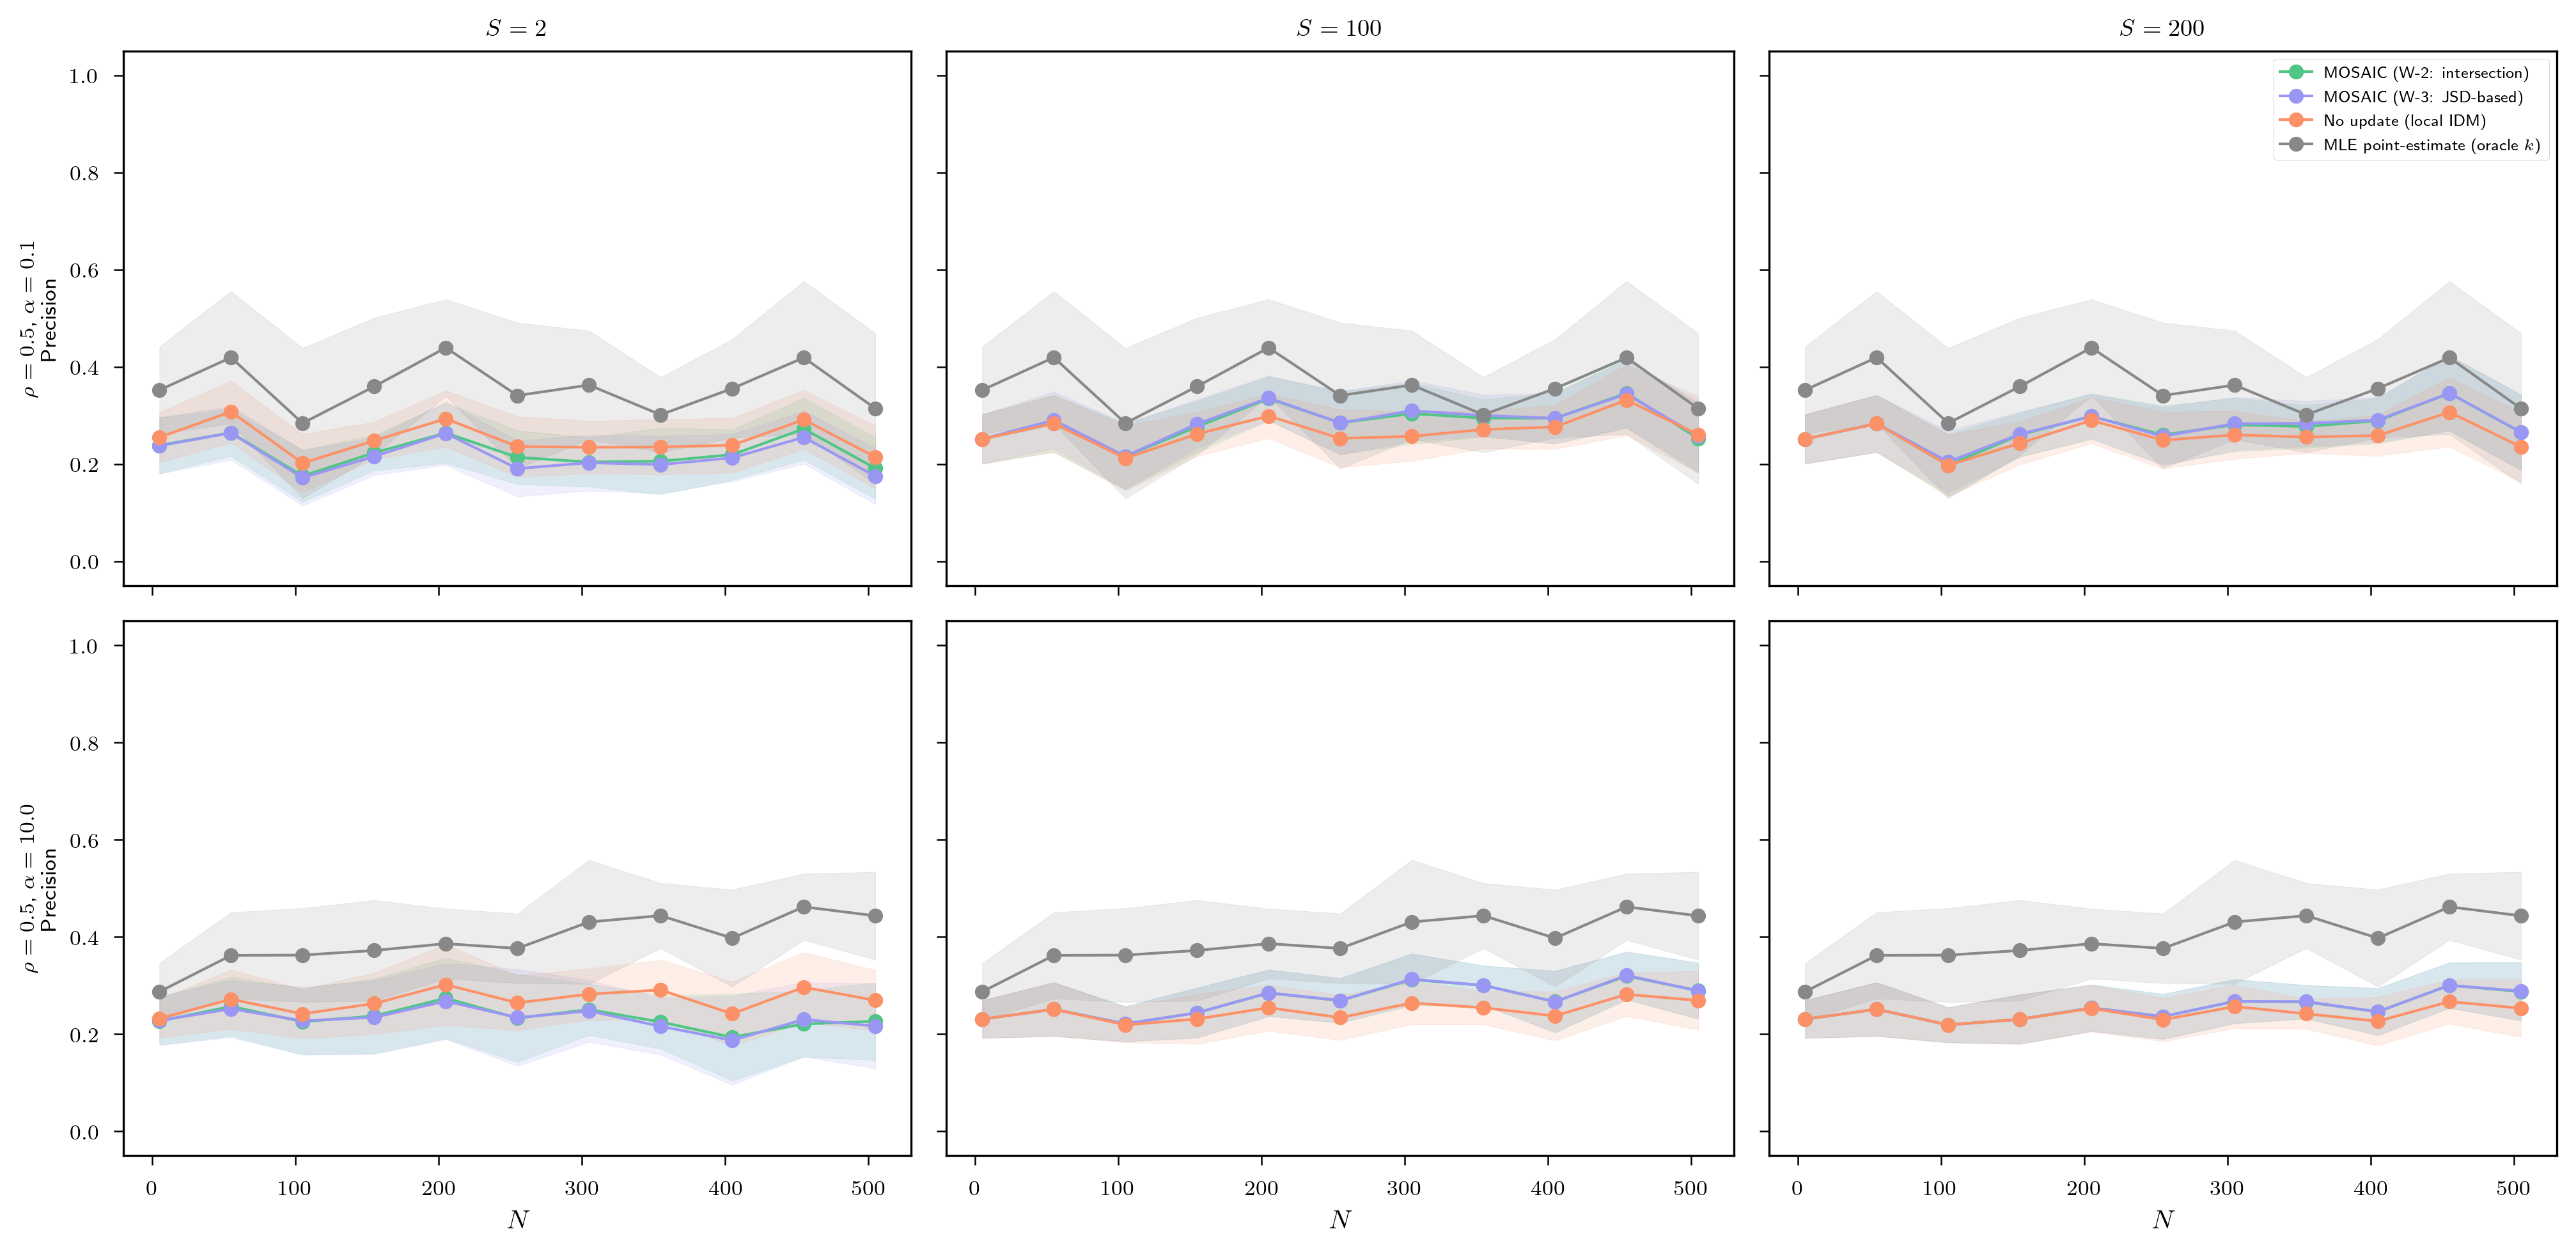

In [7]:
fig = plot_metric("precision", "Precision", ylim=(-0.05, 1.05))
plt.show()
fig.savefig(f"{res_path}_precision.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 1.2: recall (network-wide, micro-averaged)

Of all the client pairs that really *are* the same, what fraction a method
correctly found (same pooling as precision/F1). Low recall means the
method is too conservative/fragmented: it keeps apart clients that
actually share the same mechanism. Precision and recall together explain
F1's movements -- e.g. a case already found in the per-CPT section, where
low-$S$ MOSAIC's more plausible-looking cluster count did NOT mean better
clustering: both its precision AND recall were worse than the no-update
ablation's there.


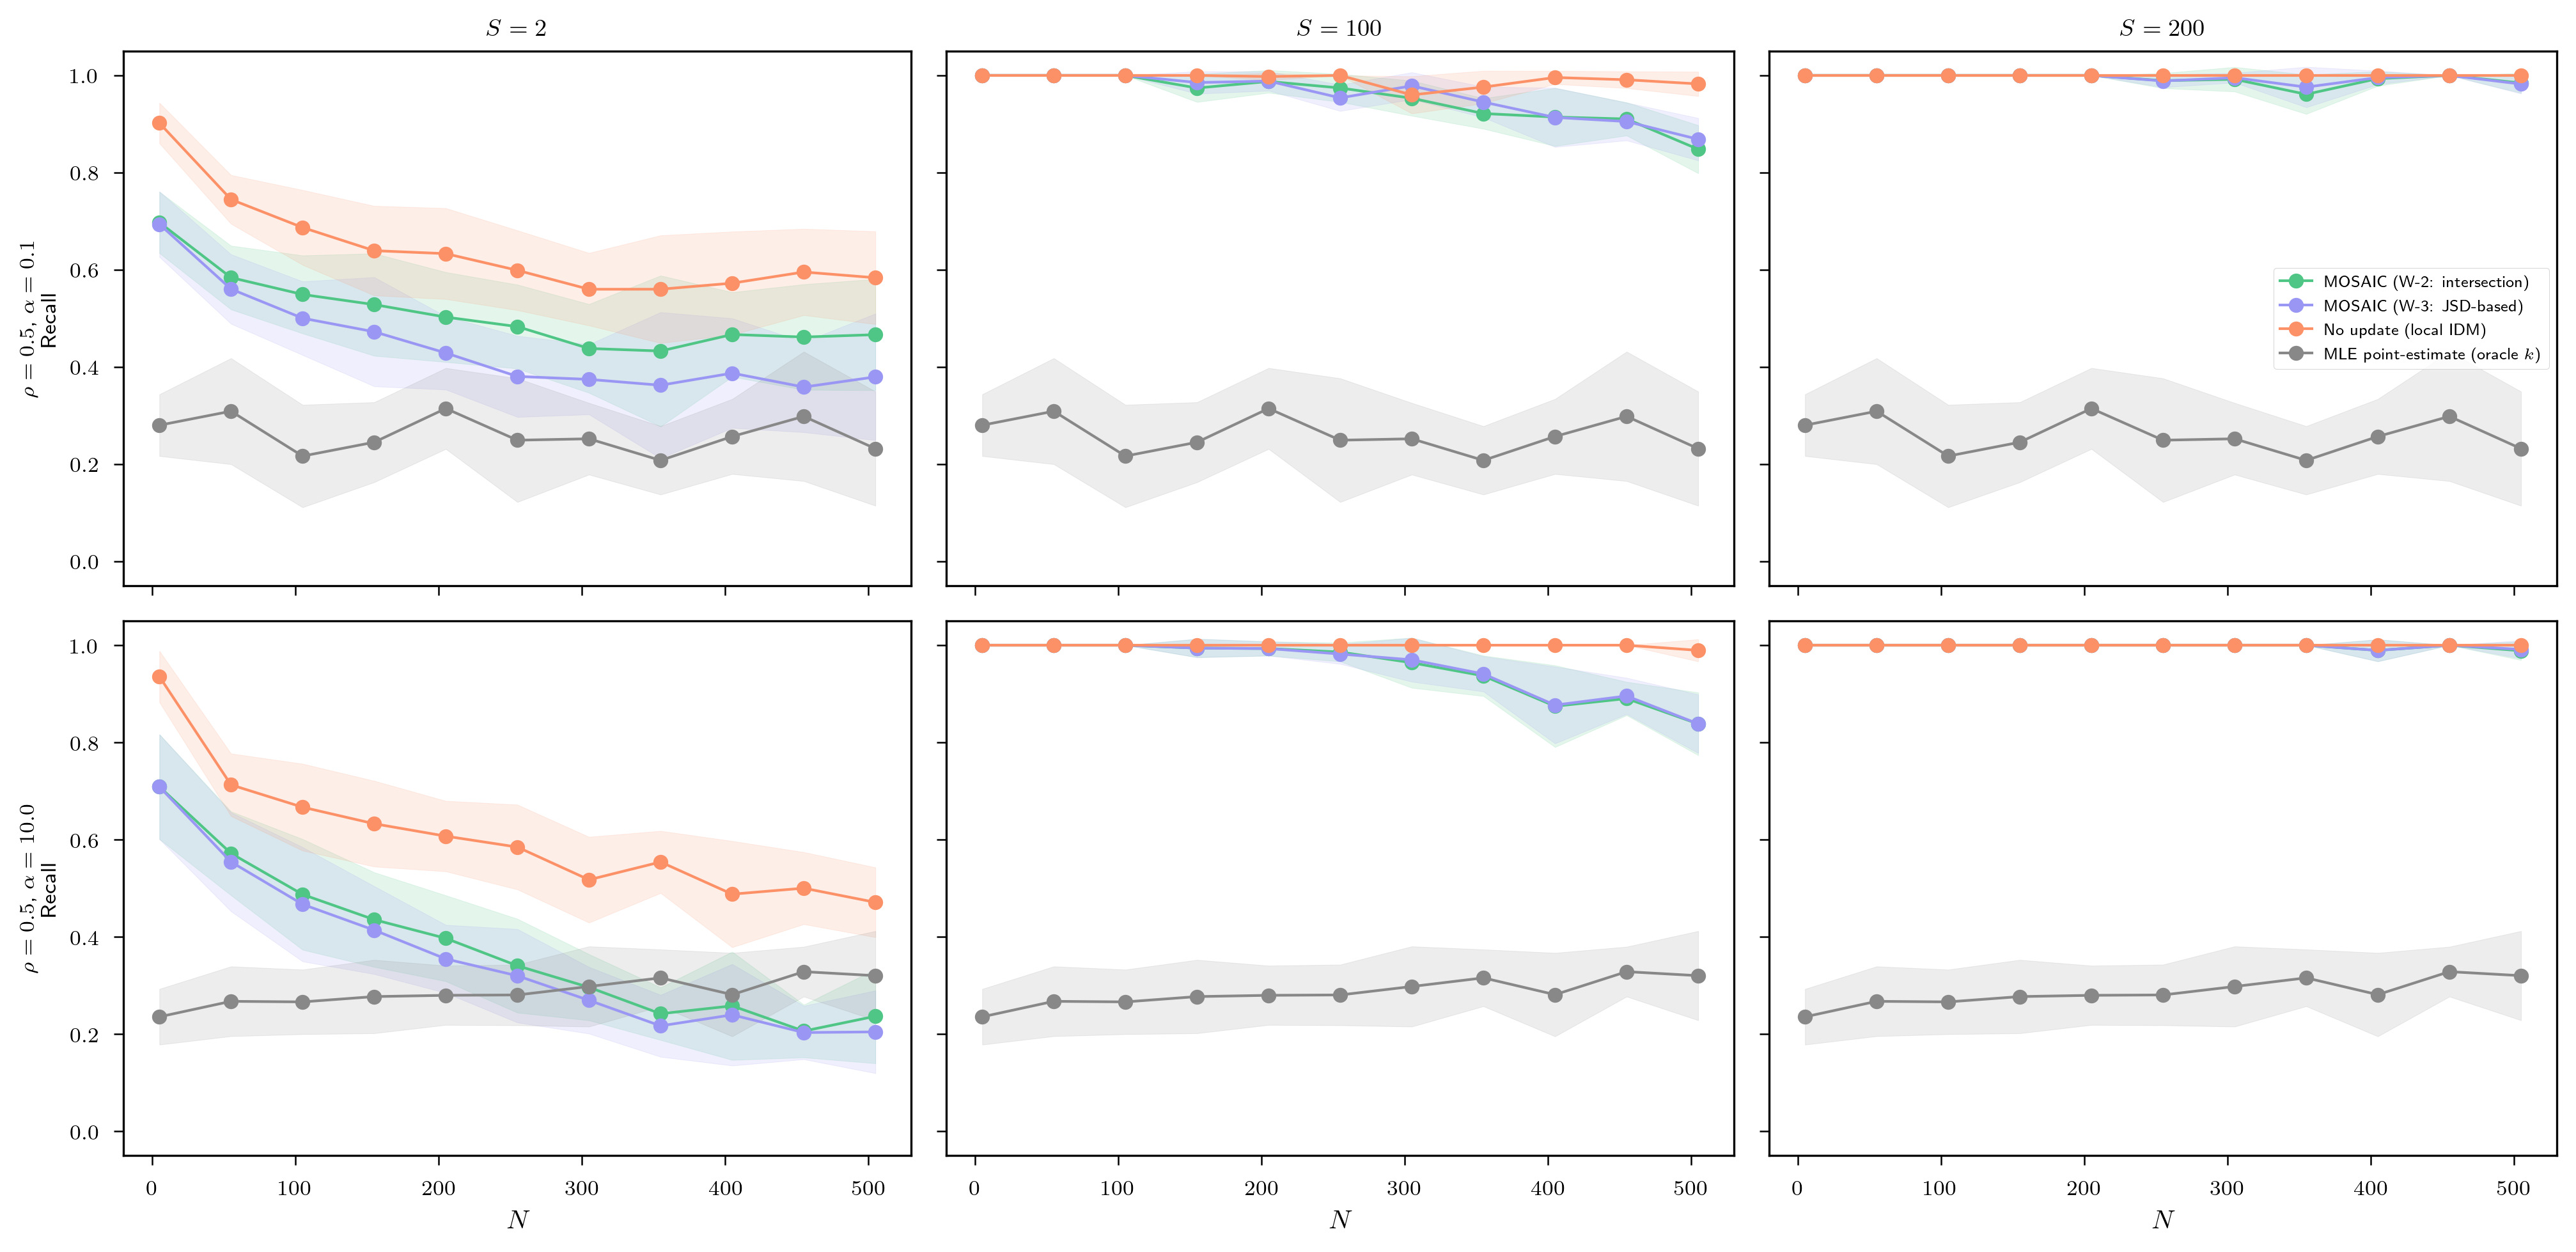

In [8]:
fig = plot_metric("recall", "Recall", ylim=(-0.05, 1.05))
plt.show()
fig.savefig(f"{res_path}_recall.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 2: Adjusted Rand Index (macro-averaged over mechanisms)

Unlike F1, ARI compares two *partitions* of the same client set, so it
cannot be pooled across mechanisms (each mechanism has its own true
partition): computed per mechanism, then macro-averaged (plain mean) across
the network's mechanisms (see `src/global_opt.py::ari_ami`), then, as
always, mean $\pm$ std across repetitions.


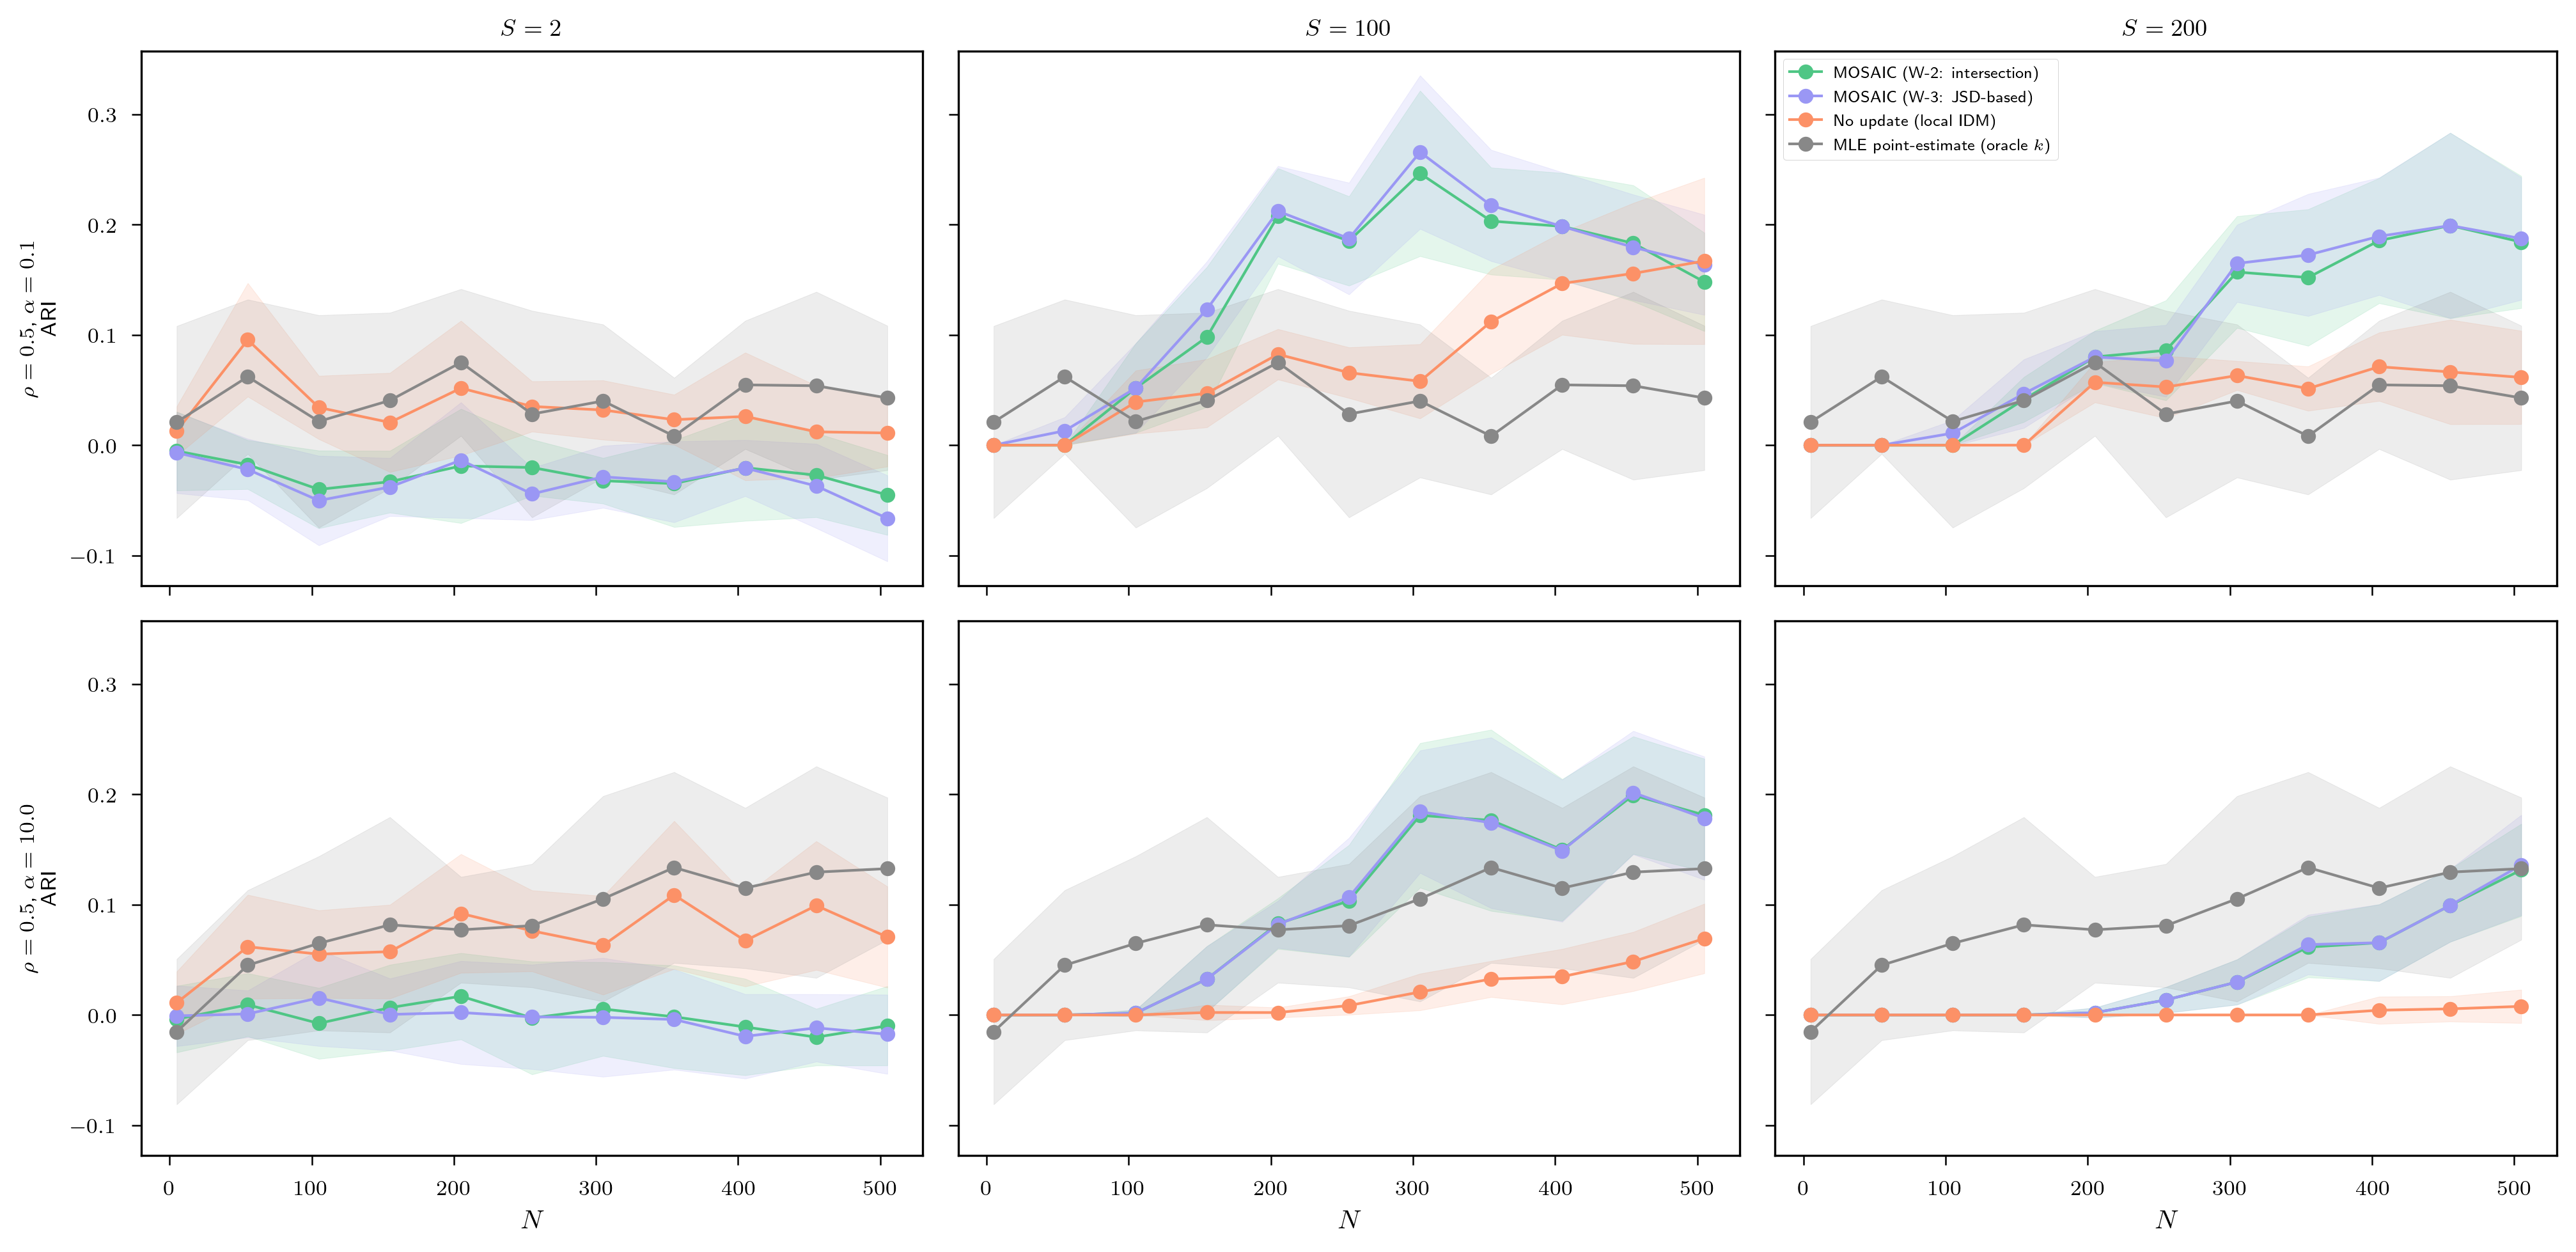

In [9]:
fig = plot_metric("ari", "ARI")
plt.show()
fig.savefig(f"{res_path}_ari.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 2.1: Adjusted Mutual Information (macro-averaged over mechanisms)

Same aggregation as ARI (per-mechanism, then macro-averaged, since -- like
ARI -- it compares two *partitions* of the same client set and so cannot
be pooled across mechanisms): computed via `src/global_opt.py::ari_ami`,
then mean $\pm$ std across repetitions, same as every other network-wide
plot. Unlike ARI (a pair-counting measure), AMI is information-theoretic
(based on mutual information between the two partitions, adjusted for
chance); the two usually agree, but AMI is less sensitive to the skewed
cluster-size distributions this task tends to produce (one large
mask-preserving cluster plus several singletons), where ARI is known to
behave less intuitively -- worth checking side by side with ARI rather
than assuming they always tell the same story.


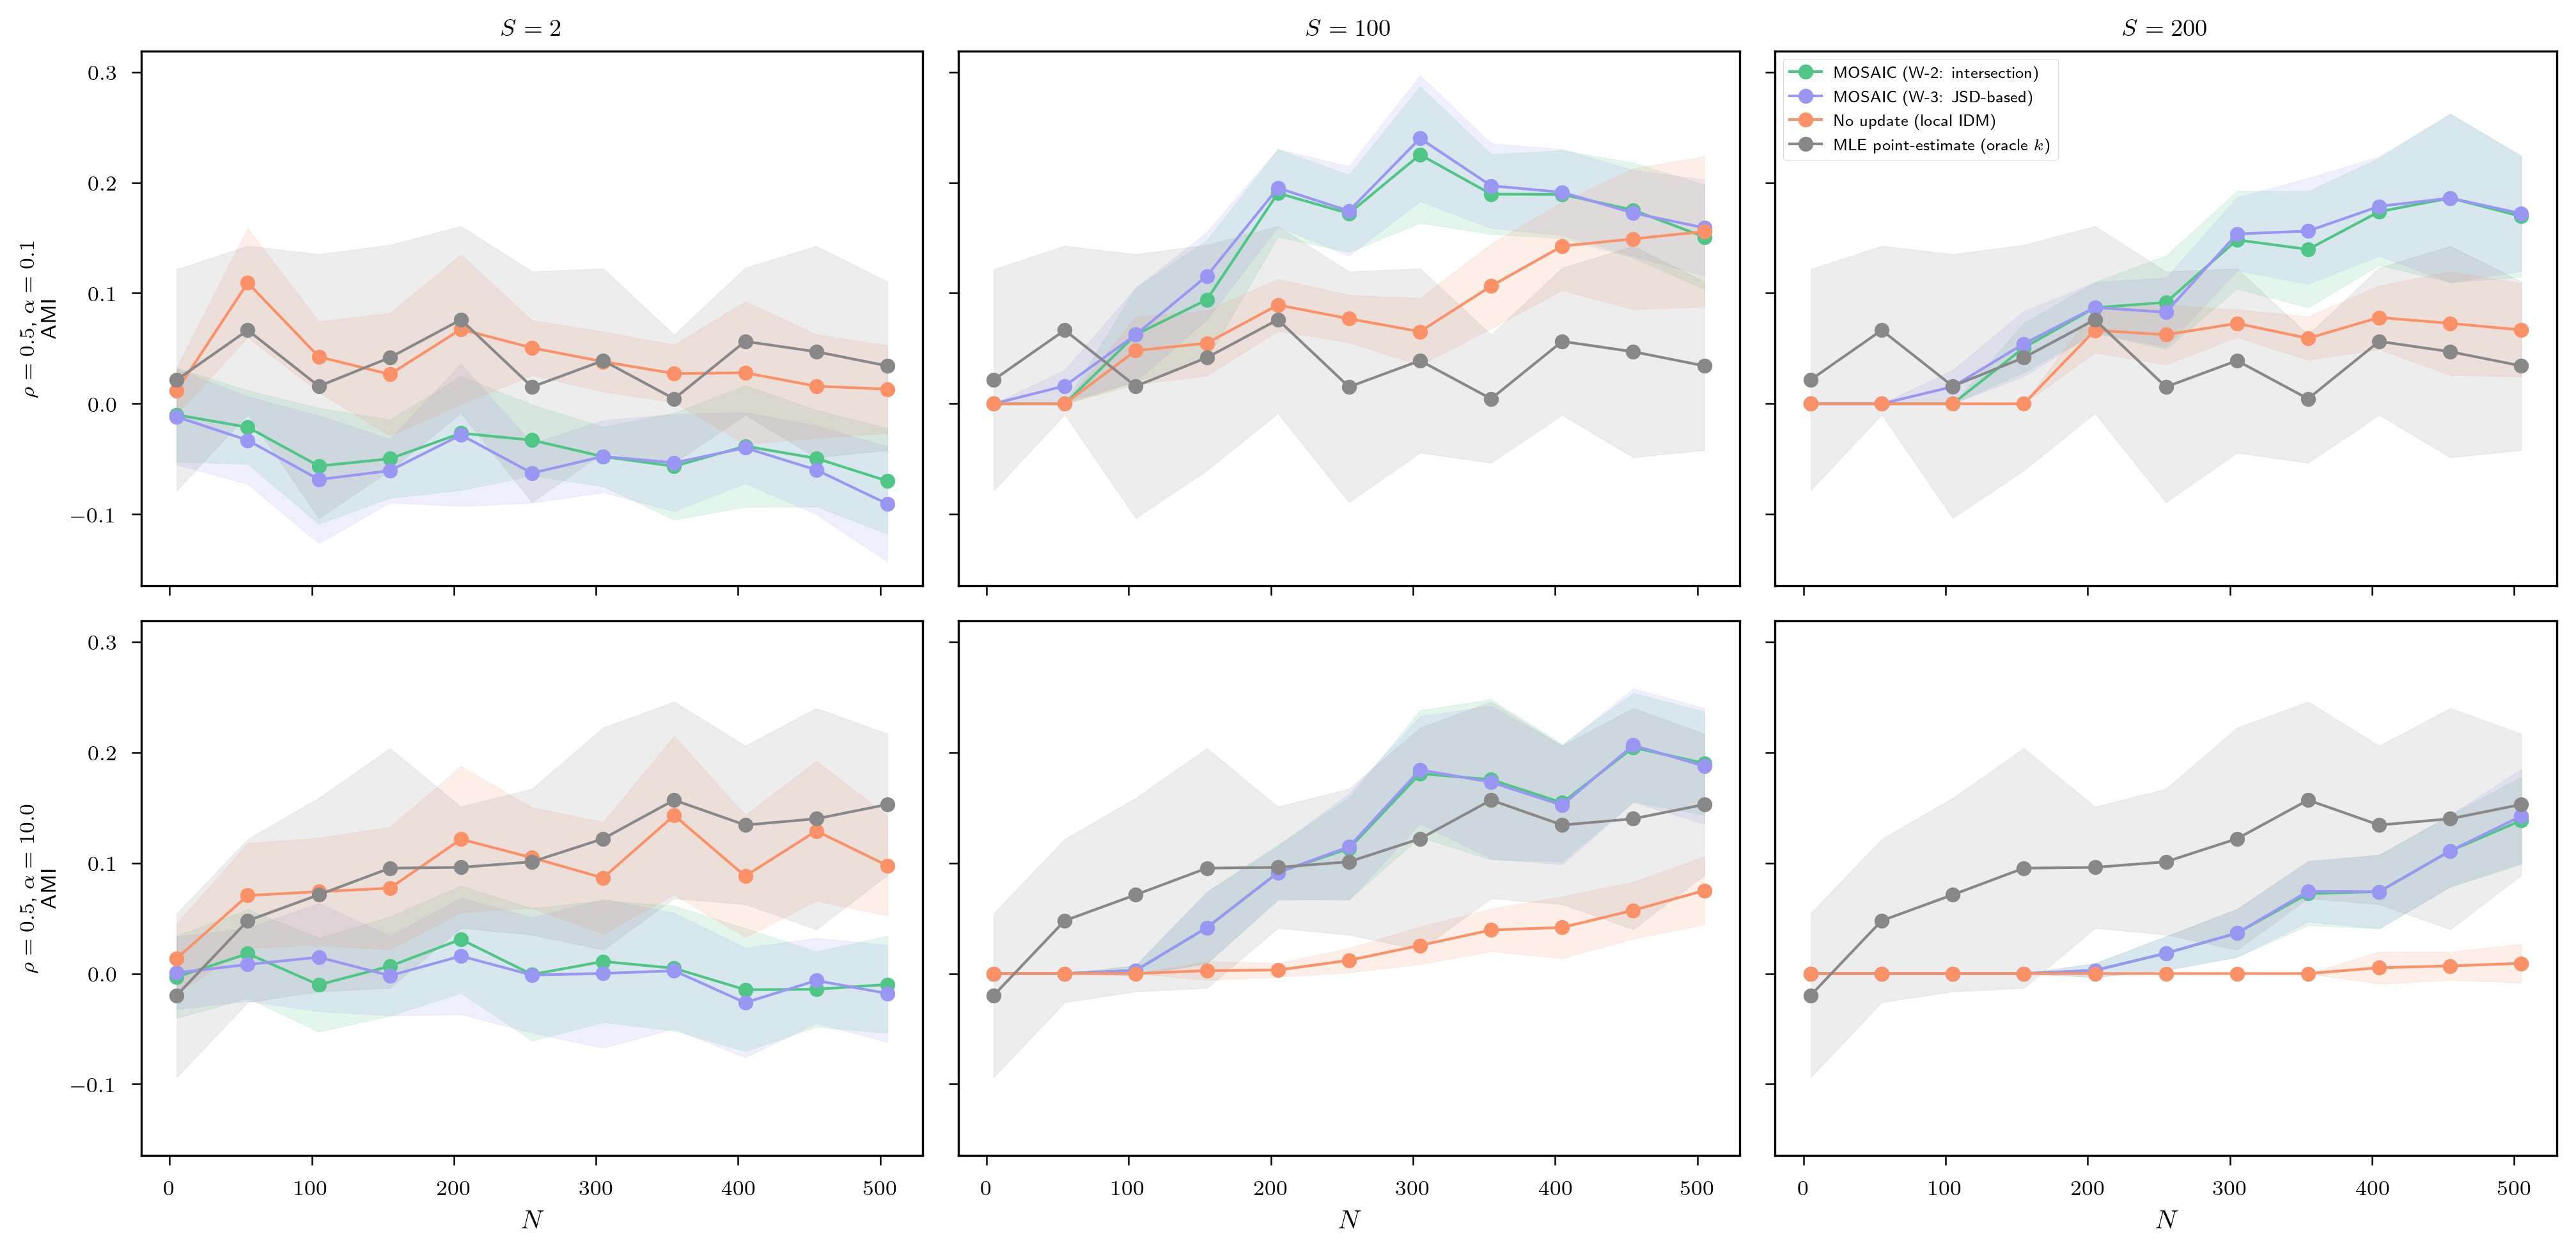

In [10]:
fig = plot_metric("ami", "AMI")
plt.show()
fig.savefig(f"{res_path}_ami.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 3: mean number of clusters found (diagnostic)

Not a headline accuracy metric, but a useful diagnostic for *why* F1/ARI
move the way they do: how many clusters each method finds, network-wide,
versus the true mean cluster count (dashed). `mle`'s baseline is handed the
true cluster count as an oracle (`cluster_mle_gaps`, see `src/global_opt.py`
-- deliberately conservative, i.e. an advantage MOSAIC does NOT get), so its
curve sits exactly on top of "True" by construction; it is shown mainly as
a visual anchor for the other three methods, which get no such help.


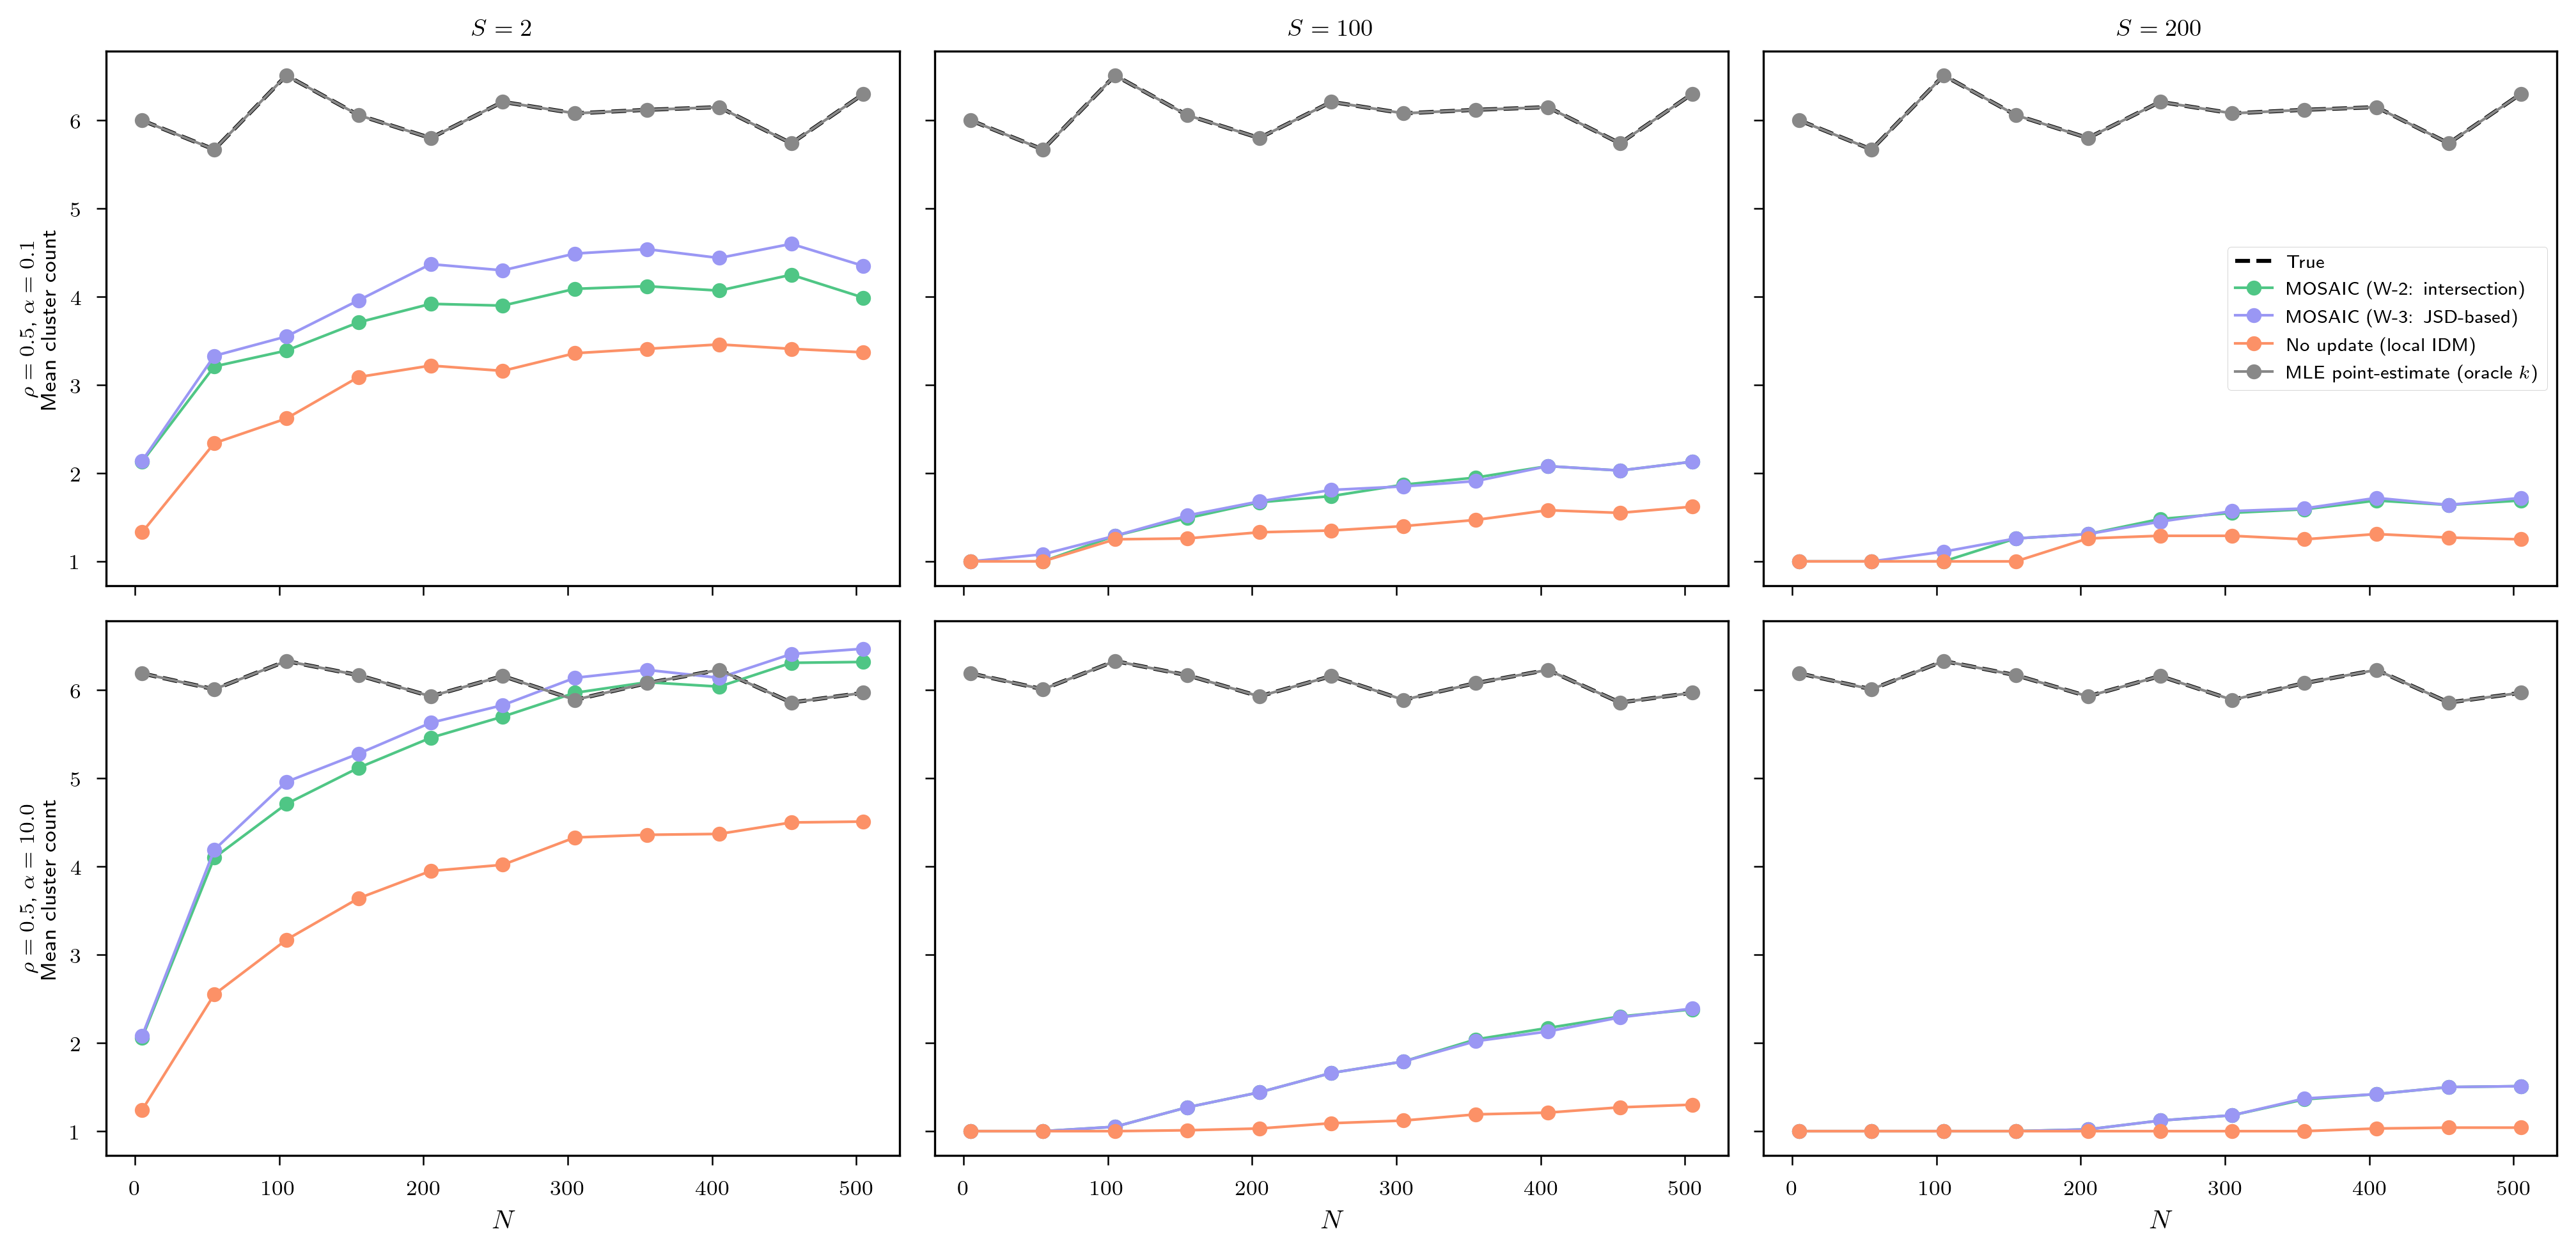

In [11]:
fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.3 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)
for i, (p, a) in enumerate(row_vals):
    for j, (nc, ess) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.plot(sub["size"], sub["n_clusters_true_mean_mean"], "k--", label="True", linewidth=1.5)
        for m in METHODS:
            ax.plot(
                sub["size"],
                sub[f"{m}_n_clusters_mean_mean"],
                color=method_colors[m],
                marker="o",
                label=method_labels[m],
            )

        if i == 0:
            ax.set_title(col_title(nc, ess), fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{row_label(p, a)}\nMean cluster count", fontsize=8)
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

axes[0][-1].legend(fontsize=7)
plt.tight_layout()
plt.show()
fig.savefig(f"{res_path}_nclusters.svg", dpi=1200, bbox_inches="tight", transparent=False)
